# Neural Network from scratch 

# 🧠 Neural Networks from Scratch

**Goal:** By the end of this notebook, you'll understand exactly what happens
when someone says "the model is training." No magic, no hand-waving.

We'll build a neural network using only NumPy (basic math), train it to solve
a problem that a single neuron *cannot* solve, and then see how PyTorch
automates what we did manually.

---

## What We'll Cover
1. **The XOR Problem** — Why we need hidden layers
2. **Building a Neural Network** — Forward pass from scratch
3. **The Training Loop** — Loss, backprop, weight updates
4. **Watching It Learn** — Visualizing training
5. **Breaking It** — What happens with bad hyperparameters
6. **PyTorch Version** — Same thing, less code

Let's go.

 Part 1: The XOR Problem

## Why XOR?

XOR (exclusive or) is a simple logical operation:
- If inputs are **different** → output 1
- If inputs are **the same** → output 0

| Input A | Input B | Output |
|---------|---------|--------|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

### The Historical Importance

In 1969, Minsky and Papert proved that a single-layer perceptron (one neuron)
**cannot learn XOR**. This caused the first "AI Winter" — people thought neural
networks were fundamentally limited.

The solution? **Hidden layers.** A network with at least one hidden layer CAN
learn XOR. This notebook proves it.

Part 1 : The XOR problem 


In [12]:
import numpy as np 
import matplotlib.pyplot as plt 


In [13]:
# Our training data: XOR
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([
    [0],
    [1],
    [1],
    [0]
])

Let's first see what the proble looks like and then try to solve it 

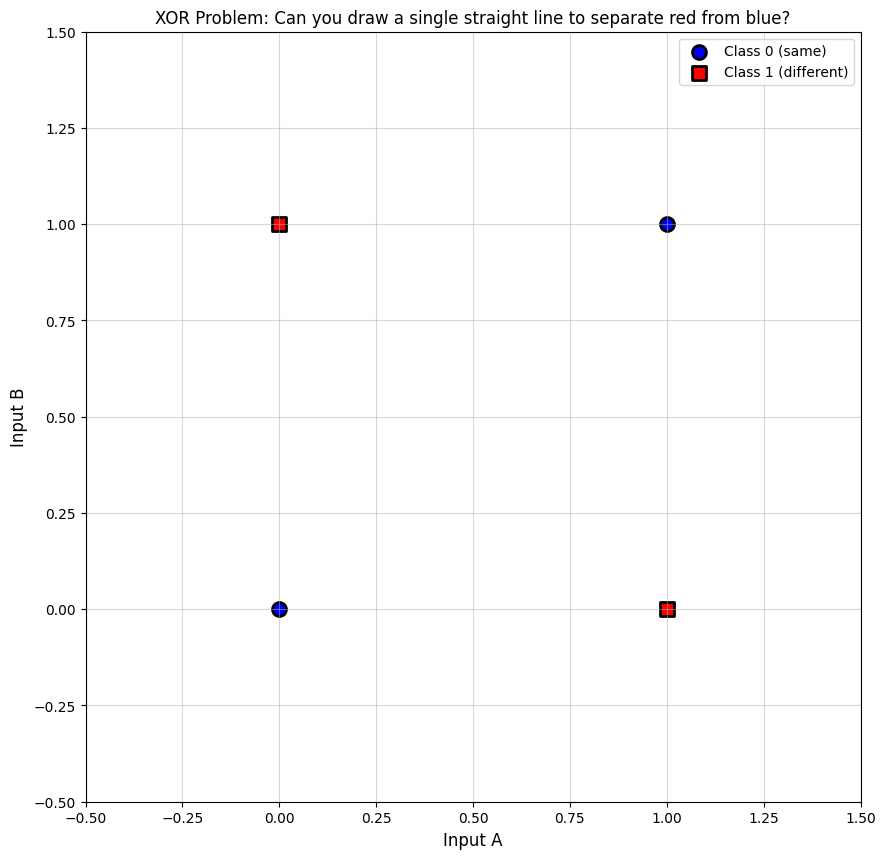


❌ A single straight line CANNOT separate these classes.
✅ This is why we need hidden layers — they create non-linear boundaries.


In [14]:
plt.figure(figsize = (10 ,10))

# plotting the dataset 

for i in range(len(X)):
    color = 'red' if y[i][0] == 1 else 'blue'
    marker = 'o' if y[i][0] == 0 else 's'
    plt.scatter(X[i][0] , X[i][1] , color = color  , marker = marker , edgecolor = 'k' , linewidth = 2 , s= 100)
plt.xlabel('Input A', fontsize=12)
plt.ylabel('Input B', fontsize=12)
plt.title('XOR Problem: Can you draw a single straight line to separate red from blue?',
          fontsize=12)
plt.xlim(-0.5 , 1.5)
plt.ylim(-0.5 , 1.5)

plt.grid(True , alpha = 0.5)
plt.legend(['Class 0 (same)', 'Class 1 (different)'], loc='upper right')
plt.show()



print("\n❌ A single straight line CANNOT separate these classes.")
print("✅ This is why we need hidden layers — they create non-linear boundaries.")


# Part 2: Building the Neural Network

## Our Architecture

```
Input Layer (2 neurons) → Hidden Layer (4 neurons) → Output Layer (1 neuron)
```

- **Input:** 2 values (the two XOR inputs)
- **Hidden:** 4 neurons with sigmoid activation
- **Output:** 1 neuron with sigmoid activation (gives us 0-1 probability)

### Why Sigmoid?

For this educational example, we use sigmoid everywhere because:
1. Output is naturally between 0 and 1 (matches our target)
2. The math is clean and easy to follow
3. It's historically important

In practice, you'd use ReLU for hidden layers. But sigmoid helps us see
what's happening.


In [15]:
# Network architecture
INPUT_SIZE = 2    # Two inputs (A and B)
HIDDEN_SIZE = 4   # Four neurons in hidden layer
OUTPUT_SIZE = 1   # One output (0 or 1)

In [16]:
#weights from the input to hidden layer (2 inputs to 4 neurons)

weights_input_hidden = np.random.randn(INPUT_SIZE , HIDDEN_SIZE) * 0.5
bias_hidden = np.zeros((1, HIDDEN_SIZE))

In [17]:
weights_input_hidden , bias_hidden

(array([[-0.21923551,  0.08068639,  0.61264859, -0.17449717],
        [ 0.30636354,  0.01157085,  0.64119821,  0.13954469]]),
 array([[0., 0., 0., 0.]]))

In [18]:
#weights from the hidden layer to the output layers  ( 2 hidden neurons and 1 output neuron )
weights_hidden_output = np.random.randn(HIDDEN_SIZE , OUTPUT_SIZE) * 0.5
bias_output= np.zeros((1 , OUTPUT_SIZE))


In [19]:
weights_hidden_output , bias_output

(array([[-0.62503585],
        [-0.9876696 ],
        [-0.48254695],
        [-0.70237838]]),
 array([[0.]]))

In [20]:
#  This sigmoid function squashes the input to the range 0 -1 
#  we also have a function that returns the derivative of the sigmoid function as well 
def Sigmoid(x):
    return 1 / ( 1 + np.exp(-x))

def sigmoid_derivative(x):
    sigmoid = Sigmoid(x)
    return sigmoid * (1 - sigmoid)



C:\Users\manas\AppData\Local\Temp\ipykernel_57676\2131905255.py:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(x_range , sigmoid_derivative(x_range) , 'b-' , label = 'sigmoid derivative' , linewidth = 3 , color = 'red')


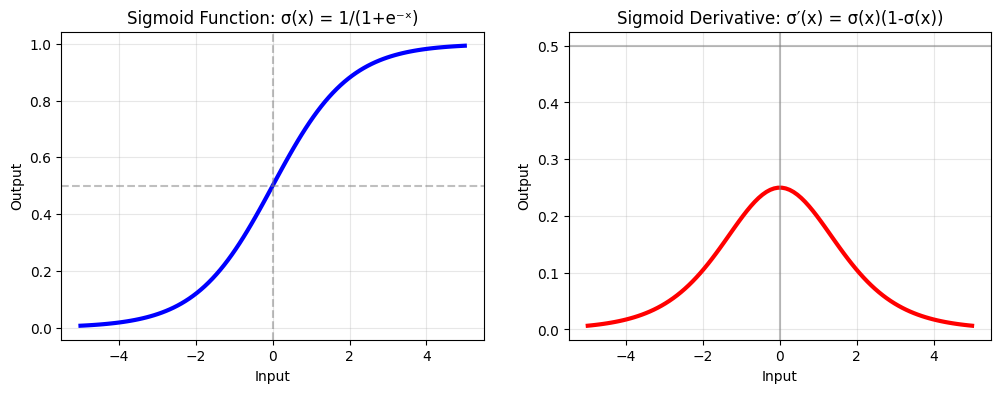

In [21]:
# now we would want to viasualize the model : 

x_range = np.linspace(-5 , 5 , 100)
plt.figure(figsize = (12 , 4))

plt.subplot(1,2,1)
plt.plot(x_range , Sigmoid(x_range) , 'b-', label = 'sigmoid' ,linewidth = 3)
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Input')
plt.ylabel('Output')
plt.title('Sigmoid Function: σ(x) = 1/(1+e⁻ˣ)')
plt.grid(True, alpha=0.3)



plt.subplot(1,2,2)
plt.plot(x_range , sigmoid_derivative(x_range) , 'b-' , label = 'sigmoid derivative' , linewidth = 3 , color = 'red')
plt.axhline(y = 0.5 , color = 'grey' , alpha = 0.5)
plt.axvline(x = 0, color = 'grey' , alpha = 0.5)
plt.xlabel('Input')
plt.ylabel('Output')
plt.title('Sigmoid Derivative: σ′(x) = σ(x)(1-σ(x))')
plt.grid(True, alpha=0.3)
plt.show()


In [22]:
print("\nNotice: The maximum derivative is only 0.25!")
print("   This is the vanishing gradient problem.")
print("   10 layers: 0.25^10 = ", 0.25**10)


Notice: The maximum derivative is only 0.25!
   This is the vanishing gradient problem.
   10 layers: 0.25^10 =  9.5367431640625e-07


## Forward Pass

The forward pass is how data flows through the network:

1. **Input → Hidden:** Multiply inputs by weights, add bias, apply activation
2. **Hidden → Output:** Multiply hidden by weights, add bias, apply activation

Let's trace through exactly what happens.

In [23]:
def forward(X):

    """forward pass through the network 
    returns al the intermediate values (we need them for the back propagation )"""

    z_hidden = np.dot(X , weights_input_hidden) + bias_hidden

    a_hidden = Sigmoid(z_hidden)

    z_output =np.dot(a_hidden , weights_hidden_output) + bias_output

    a_output =Sigmoid(z_output)

    return z_hidden , a_hidden , z_output , a_output
 

In [24]:
# Test forward pass with untrained network
z_h, a_h, z_o, predictions = forward(X)

In [25]:
print("Forward pass with UNTRAINED network:")
print("-" * 50)
for i in range(len(X)):
    print(f"Input: {X[i]} → Prediction: {predictions[i][0]:.4f} (Target: {y[i][0]})")

print("\n❌ Predictions are garbage — the network hasn't learned anything yet.")

Forward pass with UNTRAINED network:
--------------------------------------------------
Input: [0 0] → Prediction: 0.1980 (Target: 0)
Input: [0 1] → Prediction: 0.1753 (Target: 1)
Input: [1 0] → Prediction: 0.1938 (Target: 1)
Input: [1 1] → Prediction: 0.1732 (Target: 0)

❌ Predictions are garbage — the network hasn't learned anything yet.


### making of the loss function : 
the loss function measures how well the model is doing (checking the accuracy of the prediction ) 
loss--> lower the better the model 


In [26]:
def compute_loss(y_true , y_pred):
    # this is mean squared error used here 
    return np.mean((y_true - y_pred) **2)

In [27]:
predictions

array([[0.19800416],
       [0.17531118],
       [0.19376595],
       [0.17319089]])

In [28]:
# we are now going to calculate the initial loss : that would represent the 
# performance of the untrained model 
initial_loss = compute_loss(y, predictions)
print(f"Initial Loss (untrained): {initial_loss:.4f}")
print("\nThis number should decrease as we train.")

Initial Loss (untrained): 0.3498

This number should decrease as we train.


# Part 3: Backpropagation

This is where the magic happens. Backprop answers: **"Which weights caused the error, and how much?"**

## The Chain of Blame

1. Calculate error at output
2. Figure out how much each output weight contributed
3. Propagate error back to hidden layer
4. Figure out how much each hidden weight contributed
5. Adjust all weights proportionally

The math uses the chain rule from calculus, but the intuition is simple:
**blame flows backward.**

In [29]:
def backward(X, y, z_hidden, a_hidden, z_output, a_output, learning_rate):
    """
    Backpropagation: compute gradients and update weights.
    """
    global weights_input_hidden, bias_hidden, weights_hidden_output, bias_output

    m = X.shape[0]  # Number of training examples

    # ============ OUTPUT LAYER ============
    # Error at output: difference between prediction and target
    output_error = a_output - y  # Shape: (4, 1)

    # Gradient of loss w.r.t. z_output (before activation)
    # This combines the error with the sigmoid derivative
    output_delta = output_error * sigmoid_derivative(z_output)  # Shape: (4, 1)

    # Gradient of loss w.r.t. weights_hidden_output
    # How much did each weight contribute to the error?
    grad_weights_hidden_output = np.dot(a_hidden.T, output_delta) / m
    grad_bias_output = np.mean(output_delta, axis=0, keepdims=True)

    # ============ HIDDEN LAYER ============
    # Propagate error back to hidden layer
    hidden_error = np.dot(output_delta, weights_hidden_output.T)

    # Gradient of loss w.r.t. z_hidden
    hidden_delta = hidden_error * sigmoid_derivative(z_hidden)

    # Gradient of loss w.r.t. weights_input_hidden
    grad_weights_input_hidden = np.dot(X.T, hidden_delta) / m
    grad_bias_hidden = np.mean(hidden_delta, axis=0, keepdims=True)

    # ============ UPDATE WEIGHTS ============
    # Move weights in the opposite direction of the gradient
    # (gradient points uphill, we want to go downhill)
    weights_hidden_output -= learning_rate * grad_weights_hidden_output
    bias_output -= learning_rate * grad_bias_output
    weights_input_hidden -= learning_rate * grad_weights_input_hidden
    bias_hidden -= learning_rate * grad_bias_hidden


print("Backpropagation function defined.")
print("This is the 'learning' part — adjusting weights to reduce error.")

Backpropagation function defined.
This is the 'learning' part — adjusting weights to reduce error.


weights_hidden_output -= learning_rate * grad_weights_hidden_output
bias_output          -= learning_rate * grad_bias_output

weights_input_hidden -= learning_rate * grad_weights_input_hidden
bias_hidden          -= learning_rate * grad_bias_hidden


### The training Loop 

Now we put it all together:

```
for each iteration:
    1. Forward pass → get predictions
    2. Calculate loss → how wrong are we?
    3. Backward pass → compute gradients, update weights
```

Let's train for 10,000 iterations and watch the loss decrease.

In [30]:
# Reset weights (in case you run this cell multiple times)
np.random.seed(42)
weights_input_hidden = np.random.randn(INPUT_SIZE, HIDDEN_SIZE) * 0.5
bias_hidden = np.zeros((1, HIDDEN_SIZE))
weights_hidden_output = np.random.randn(HIDDEN_SIZE, OUTPUT_SIZE) * 0.5
bias_output = np.zeros((1, OUTPUT_SIZE))

In [31]:
# Hyperparameters
learning_rate = 2.0  # How big our steps are
iterations = 10000   # How many times to loop

In [32]:
# Track loss over time
loss_history = []

In [33]:
print("training started.......")
print("-" * 50)

for i in range(iterations):
    # forward propagation 
    z_h , a_h , z_o , predictions = forward(X)

    #calculate the loss 
    loss = compute_loss(y , predictions)
    loss_history.append(loss)

    #backward propagation (the magic happens here ) updates the weights internally 
    backward(X , y, z_h , a_h , z_o , predictions , learning_rate)

    # printing the progress 

    if i % 2000 == 0 :
        print(f"iteration {i:5d} | Loss:{ loss :.6f}")


training started.......
--------------------------------------------------
iteration     0 | Loss:0.255675
iteration  2000 | Loss:0.005210
iteration  4000 | Loss:0.001005
iteration  6000 | Loss:0.000529
iteration  8000 | Loss:0.000355


In [34]:
# Final predictions
_, _, _, final_predictions = forward(X)

print("Final Results After Training:")
print("-" * 50)
print(f"{'Input':<12} {'Target':<10} {'Prediction':<12} {'Rounded':<10}")
print("-" * 50)

for i in range(len(X)):
    pred = final_predictions[i][0]
    rounded = round(pred)
    status = "✅" if rounded == y[i][0] else "❌"
    print(f"{str(X[i]):<12} {y[i][0]:<10} {pred:<12.4f} {rounded:<10} {status}")

print("-" * 50)
print(f"\n🎉 The network learned XOR from random weights!")

Final Results After Training:
--------------------------------------------------
Input        Target     Prediction   Rounded   
--------------------------------------------------
[0 0]        0          0.0187       0          ✅
[0 1]        1          0.9845       1          ✅
[1 0]        1          0.9844       1          ✅
[1 1]        0          0.0151       0          ✅
--------------------------------------------------

🎉 The network learned XOR from random weights!


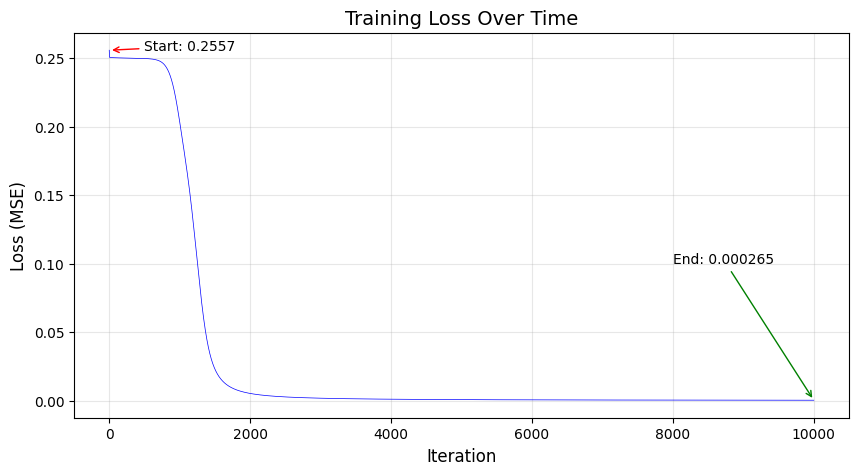

The loss started high (random guessing) and decreased (learning).


In [35]:

plt.figure(figsize=(10, 5))
plt.plot(loss_history, 'b-', linewidth=0.5)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Training Loss Over Time', fontsize=14)
plt.grid(True, alpha=0.3)

# Add annotations
plt.annotate(f'Start: {loss_history[0]:.4f}',
             xy=(0, loss_history[0]), fontsize=10,
             xytext=(500, loss_history[0]),
             arrowprops=dict(arrowstyle='->', color='red'))
plt.annotate(f'End: {loss_history[-1]:.6f}',
             xy=(len(loss_history)-1, loss_history[-1]), fontsize=10,
             xytext=(len(loss_history)-2000, 0.1),
             arrowprops=dict(arrowstyle='->', color='green'))

plt.show()

print("The loss started high (random guessing) and decreased (learning).")

# Part 5: Breaking It (Experiments)

Understanding what breaks a network teaches you more than seeing it work.
Try these experiments:

## Experiment 1: Learning Rate Too High

In [36]:
# Reset and train with learning rate = 100 (way too high)
np.random.seed(42)
weights_input_hidden = np.random.randn(INPUT_SIZE, HIDDEN_SIZE) * 0.5
bias_hidden = np.zeros((1, HIDDEN_SIZE))
weights_hidden_output = np.random.randn(HIDDEN_SIZE, OUTPUT_SIZE) * 0.5
bias_output = np.zeros((1, OUTPUT_SIZE))

lr_high = 100.0
loss_high_lr = []

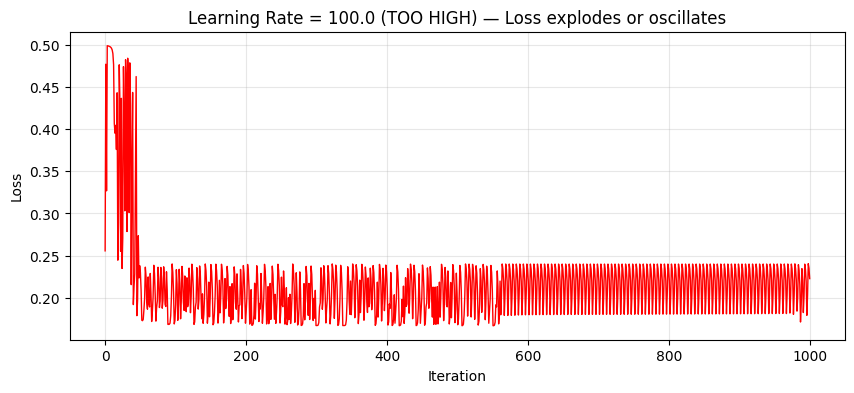

In [37]:
for i in range(1000):
    z_h, a_h, z_o, pred = forward(X)
    loss_high_lr.append(compute_loss(y, pred))
    backward(X, y, z_h, a_h, z_o, pred, lr_high)

plt.figure(figsize=(10, 4))
plt.plot(loss_high_lr, 'r-', linewidth=1)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title(f'Learning Rate = {lr_high} (TOO HIGH) — Loss explodes or oscillates')
plt.grid(True, alpha=0.3)
plt.show()

# Experiment 2 - learning rate too low 

In [38]:
# Reset and train with learning rate = 0.001 (too low)
np.random.seed(42)
weights_input_hidden = np.random.randn(INPUT_SIZE, HIDDEN_SIZE) * 0.5
bias_hidden = np.zeros((1, HIDDEN_SIZE))
weights_hidden_output = np.random.randn(HIDDEN_SIZE, OUTPUT_SIZE) * 0.5
bias_output = np.zeros((1, OUTPUT_SIZE))

lr_low = 0.001
loss_low_lr = []

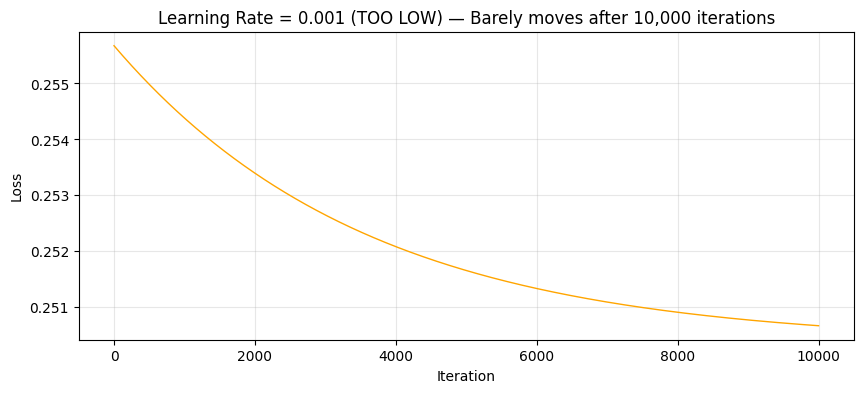

Predictions with low learning rate:
  [0 0] → 0.4977 (target: 0)
  [0 1] → 0.4852 (target: 1)
  [1 0] → 0.4828 (target: 1)
  [1 1] → 0.4716 (target: 0)

❌ With learning rate too low, learning is painfully slow.


In [39]:
for i in range(10000):
    z_h, a_h, z_o, pred = forward(X)
    loss_low_lr.append(compute_loss(y, pred))
    backward(X, y, z_h, a_h, z_o, pred, lr_low)

plt.figure(figsize=(10, 4))
plt.plot(loss_low_lr, 'orange', linewidth=1)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title(f'Learning Rate = {lr_low} (TOO LOW) — Barely moves after 10,000 iterations')
plt.grid(True, alpha=0.3)
plt.show()

final_pred_low = forward(X)[3]
print("Predictions with low learning rate:")
for i in range(len(X)):
    print(f"  {X[i]} → {final_pred_low[i][0]:.4f} (target: {y[i][0]})")
print("\n❌ With learning rate too low, learning is painfully slow.")

# Experiment 3 : Less numeber of nuerons 

In [40]:
# Try with only 2 hidden neurons
np.random.seed(42)
w_ih_small = np.random.randn(2, 2) * 0.5  # Only 2 hidden neurons
b_h_small = np.zeros((1, 2))
w_ho_small = np.random.randn(2, 1) * 0.5
b_o_small = np.zeros((1, 1))

In [41]:
def forward_small(X):
    z_h = np.dot(X, w_ih_small) + b_h_small
    a_h = sigmoid(z_h)
    z_o = np.dot(a_h, w_ho_small) + b_o_small
    a_o = sigmoid(z_o)
    return z_h, a_h, z_o, a_o

In [42]:
loss_small = []
for i in range(10000):
    z_h, a_h, z_o, pred = forward_small(X)
    loss_small.append(compute_loss(y, pred))
    backward_small(X, y, z_h, a_h, z_o, pred, 2.0)

plt.figure(figsize=(10, 4))
plt.plot(loss_small, 'purple', linewidth=1)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Only 2 Hidden Neurons — Network struggles to learn XOR')
plt.grid(True, alpha=0.3)
plt.show()

final_small = forward_small(X)[3]
print("Predictions with only 2 hidden neurons:")
for i in range(len(X)):
    print(f"  {X[i]} → {final_small[i][0]:.4f} (target: {y[i][0]})")
print("\n⚠️  With fewer neurons, the network may not have enough capacity.")

NameError: name 'sigmoid' is not defined


---
# Part 6: The PyTorch Version

Now let's see the same thing in PyTorch. Notice:
- `loss.backward()` does all the backprop math automatically
- `optimizer.step()` updates the weights automatically

**The concepts are identical. The code is cleaner.**


In [43]:
!pip install torch


Looking in indexes: https://pypi.org/simple/



[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [44]:
import torch 
import torch.nn as nn 
import torch.optim as optim 

# Convert the data to pytorch tensors 
X_tensor = torch.FloatTensor(X)
y_tensor = torch.FloatTensor(y)

# Define the model architecture 
class XORNet(nn.Module):
    def __init__(self):
        super(XORNet , self).__init__()
        self.hidden = nn.Linear(2 ,4)       # this means 2 input and 4 hiddne 
        self.output = nn.Linear(4 , 1)      # this means 4 hidden and 1 output 
        self.sigmoid = nn.Sigmoid()

    def forward(self , X):
        X = self.sigmoid(self.hidden(X))
        X = self.sigmoid(self.output(X))
        return X

# creating the network 
torch.manual_seed(42)
model = XORNet()

# loss function and optimization 
criterian = nn.MSELoss()
optimizer = optim.SGD(model.parameters() , lr = 2.0)


# training loop 
pytorch_loss_history = []

print("training pytorch model")
print("-" *50)

for i in range(10000):

    # sabse pehle forward passs 
    prediciton = model(X_tensor)
    loss = criterian(prediciton , y_tensor)
    pytorch_loss_history.append(loss.item())

    # backward pass (automatic differentiation )
    optimizer.zero_grad()           # clearn the pervious gradients 
    loss.backward()             # computess the gradients (this is actual back propagation )
    optimizer.step()            # upates the weights

    if i % 2000 == 0:
        print(f"Iteration {i:5d} | Loss: {loss.item():.6f}")

print("-" * 50)
print(f"Iteration {10000:5d} | Loss: {pytorch_loss_history[-1]:.6f}")

training pytorch model
--------------------------------------------------
Iteration     0 | Loss: 0.286560
Iteration  2000 | Loss: 0.000779
Iteration  4000 | Loss: 0.000298
Iteration  6000 | Loss: 0.000179
Iteration  8000 | Loss: 0.000127
--------------------------------------------------
Iteration 10000 | Loss: 0.000098


In [45]:
# Compare results
print("\nPyTorch Final Predictions:")
print("-" * 50)
with torch.no_grad():
    final_preds = model(X_tensor)
    for i in range(len(X)):
        pred = final_preds[i].item()
        print(f"Input: {X[i]} → Prediction: {pred:.4f} (Target: {y[i][0]})")


PyTorch Final Predictions:
--------------------------------------------------
Input: [0 0] → Prediction: 0.0091 (Target: 0)
Input: [0 1] → Prediction: 0.9890 (Target: 1)
Input: [1 0] → Prediction: 0.9913 (Target: 1)
Input: [1 1] → Prediction: 0.0105 (Target: 0)


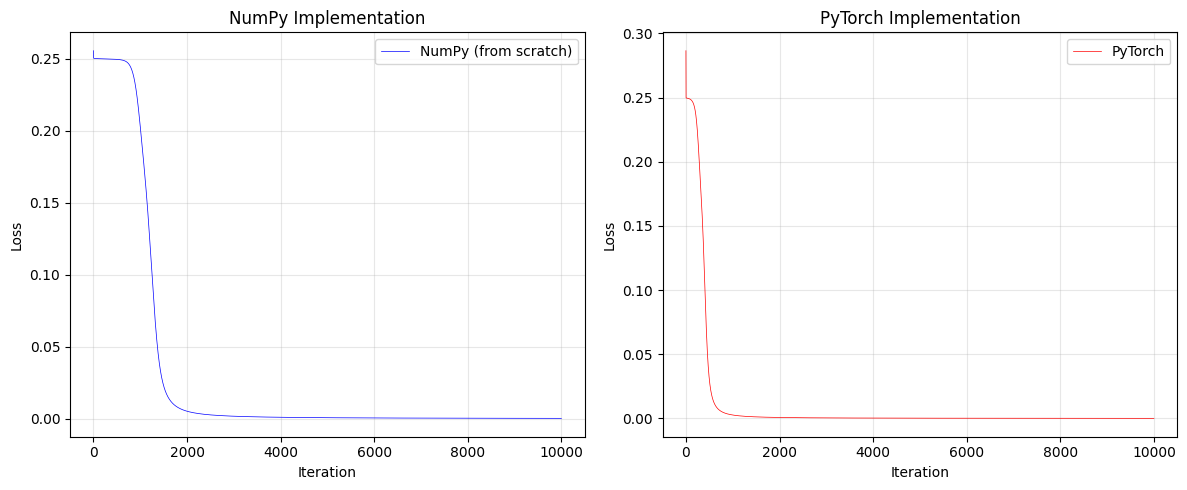


✅ Both implementations achieve the same result!
   PyTorch just automates the gradient calculations.


In [46]:
# Compare loss curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(loss_history, 'b-', linewidth=0.5, label='NumPy (from scratch)')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('NumPy Implementation')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(pytorch_loss_history, 'r-', linewidth=0.5, label='PyTorch')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('PyTorch Implementation')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

print("\n✅ Both implementations achieve the same result!")
print("   PyTorch just automates the gradient calculations.")